In [107]:
import solver, validator
import file_manager as fm
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

importlib.reload(solver)
importlib.reload(validator)
importlib.reload(fm)

<module 'file_manager' from '/Users/reuter/Documents/Cambridge/SRIM/neural/file_manager.py'>

In [ ]:
# dtype = torch.float64
# device = torch.device("cpu")

# theta_1 = torch.nn.Parameter(torch.as_tensor(theta_amp_initial, dtype=dtype,device=device).clone())
# theta_2 = torch.nn.Parameter(torch.as_tensor(theta_phase_initial, dtype=dtype,device=device).clone())

In [159]:
# theta_amp_initial = np.array([  3.72688684,  -8.66370198,  -4.52485751,  -3.63420301,
#          8.39016518,  22.0520419 ,  11.8855687 , -10.07123414,
#          6.31198641,  -6.44792308,  -6.88839233,  -5.39316903,
#         -3.53666167])


# theta_phase_initial = np.array([ 2.32026118e-02,  1.38276247e-02,  1.86365318e-02,  2.30379838e-02,
#        -5.27642228e-03, -1.16231611e-02,  3.99272956e+00,  6.67027706e+00,
#         9.32439296e+00,  1.18731508e+01, -6.83404835e-01, -2.55357464e+00,
#        -5.76320983e+00, -1.03325956e+01])
# eM_trial = 85

theta_1, theta_2, seed_info = fm.load_C1_seed("seeds/C1_seed_35_p4.npz", device="cpu", dtype=torch.float64)
print(seed_info)
eM_trial = 30

{'eM': 35.0, 'q': 1.0, 'lam': 0.0, 'm_over_e': 0.0, 'k': 1, 'p_amp': 4, 'p_phase': 4, 'loss': 8.860246041368638e-17, 'diagnostics': {'charge_residual': -7.30479454702504e-09, 'Re_Phi_U_1': -4.6474419454489713e-07, 'Im_Phi_U_1': 3.803054535178596e-08, 'residual_norm': 4.6635485283881595e-07, 'max_residual': 4.6474419454489713e-07, 'inf_xi': 0.005365295142201491, 'sup_rU': -0.07606840496346971, 'I_theta': 0.028571428362720155, 'phase_winding': 1.6604841254726408, 'min_domega': 0.38119053064745323, 'max_domega': 3.1195667761436523, 'min_r': 0.005365295142201491, 'rV_0': 3.235202593362277, 'rU_0': -0.0772749133278174, 'interpolated_min_focusing': 1.0367515921726504e-07, 'ode_nfev': 7532, 'ode_njev': 0, 'ode_nlu': 0, 'ode_message': 'The solver successfully reached the end of the integration interval.', 'matching_ok': True, 'xi_ok': True, 'rU_ok': True, 'finite': True, 'valid': True}}


In [160]:
coarse_n_grid = 1001
fine_n_grid = 4001
coarse_loss_tol = 1e-8
fine_loss_tol = 1e-16

def objective_C1(n_grid):
    return solver.loss_C1(theta_1, theta_2, eM_trial, q=1, rho_drho_func=solver.tanh_ansatz, omega_domega_func=solver.omega_domega, n_grid=n_grid)

In [ ]:
print(f"Coarse stage: n_grid={coarse_n_grid}")
coarse_result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=lambda: objective_C1(coarse_n_grid),
    lr=1e-3,
    max_iter=1000,
    loss_tol=coarse_loss_tol,
    grad_tol=1e-10,
    patience=200,
)

with torch.no_grad():
    theta_1.copy_(coarse_result["best_params"][0])
    theta_2.copy_(coarse_result["best_params"][1])

print(f"Fine stage: n_grid={fine_n_grid}")
result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=lambda: objective_C1(fine_n_grid),
    lr=1e-3,
    max_iter=1000,
    loss_tol=fine_loss_tol,
    grad_tol=1e-10,
    patience=200,
)

Coarse stage: n_grid=1001
step=    0, loss=2.040866e-02, best=2.040866e-02, |g|=3.164305e-01
step=   20, loss=8.800357e-03, best=8.800357e-03, |g|=2.121782e-01
step=   40, loss=5.610648e-03, best=5.610648e-03, |g|=7.411027e-02
step=   60, loss=3.673151e-03, best=3.673151e-03, |g|=6.237188e-02
step=   80, loss=2.180735e-03, best=2.180735e-03, |g|=4.658468e-02
step=  100, loss=1.205929e-03, best=1.205929e-03, |g|=3.453340e-02
step=  120, loss=6.444554e-04, best=6.444554e-04, |g|=2.355368e-02
step=  140, loss=3.643301e-04, best=3.643301e-04, |g|=1.570632e-02
step=  160, loss=2.397013e-04, best=2.397013e-04, |g|=1.027176e-02
step=  180, loss=1.849912e-04, best=1.849912e-04, |g|=6.967558e-03
step=  200, loss=1.564596e-04, best=1.564596e-04, |g|=5.190504e-03
step=  220, loss=1.367024e-04, best=1.367024e-04, |g|=4.269768e-03
step=  240, loss=1.201472e-04, best=1.201472e-04, |g|=3.764451e-03
step=  260, loss=1.053148e-04, best=1.053148e-04, |g|=3.428793e-03
step=  280, loss=9.186102e-05, best=

In [155]:
best_theta_1_torch, best_theta_2_torch = result["best_params"]

best_theta_1 = (best_theta_1_torch.detach().cpu().numpy())
best_theta_2 = (best_theta_2_torch.detach().cpu().numpy())

print("coarse best loss:", coarse_result["best_loss"])
print("coarse stop reason:", coarse_result["stop_reason"])
print("fine best loss:", result["best_loss"])
print("fine stop reason:", result["stop_reason"])

coarse best loss: 9.816603927789554e-09
coarse stop reason: loss tolerance reached
fine best loss: 8.860246041368638e-17
fine stop reason: loss tolerance reached


In [156]:
validation = validator.validate_C1(
    theta_amp=best_theta_1,
    theta_phase=best_theta_2,
    eM=eM_trial,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    k=1,
    rho_drho_func=solver.tanh_ansatz,
    omega_domega_func=solver.omega_domega,
    rplus_and_Qtarget_func=solver.rplus_and_Qtarget,
    ansatz_backend="torch",
    n_grid=10001,
    n_profile=10001,
    rtol=1e-11,
    atol=1e-13,
    max_step=2e-3,
    match_tol=1e-6,
    xi_margin=0.0,
    rU_margin=0.0,
)

C1 SCIPY VALIDATION: VALID

Matching residuals
  Q(1)-Q_target       = -7.304794547025e-09
  Re Phi_U(1)         = -4.647441945449e-07
  Im Phi_U(1)         = +3.803054535179e-08
  residual L2 norm    = 4.663548528388e-07
  largest residual    = 4.647441945449e-07

Admissibility
  inf xi              = +5.365295142201e-03
  sup r_U             = -7.606840496347e-02
  xi condition        = True
  r_U condition       = True

Phase
  omega(1)-omega(0)   = +1.660484125473e+00
  min omega'          = +3.811905306475e-01
  max omega'          = +3.119566776144e+00

Numerics
  grid points         = 10001
  profile points      = 10001
  DOP853 evaluations  = 7532
  interpolated min E  = +1.036751592173e-07
  matching tolerance  = 1.000e-06


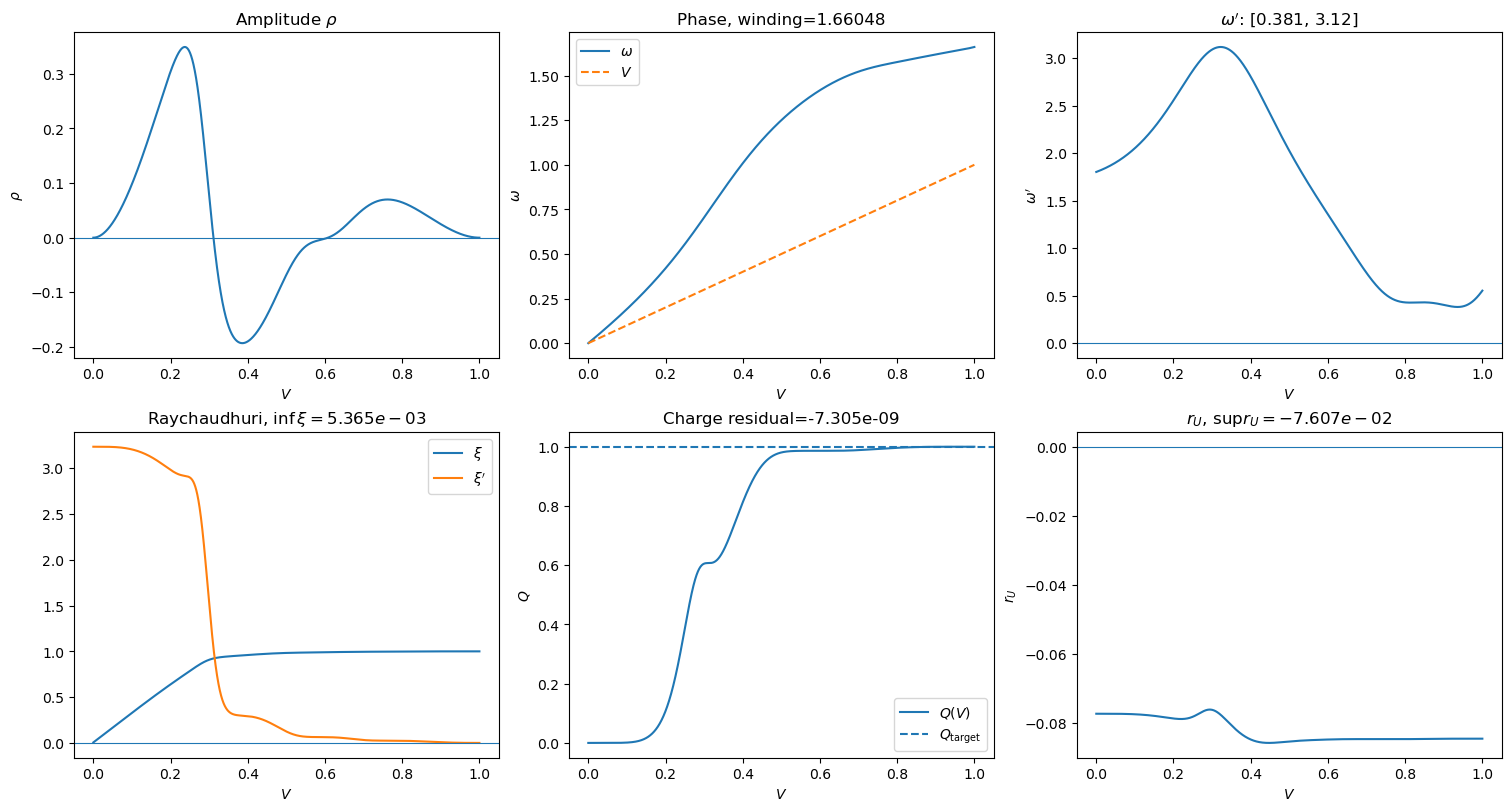

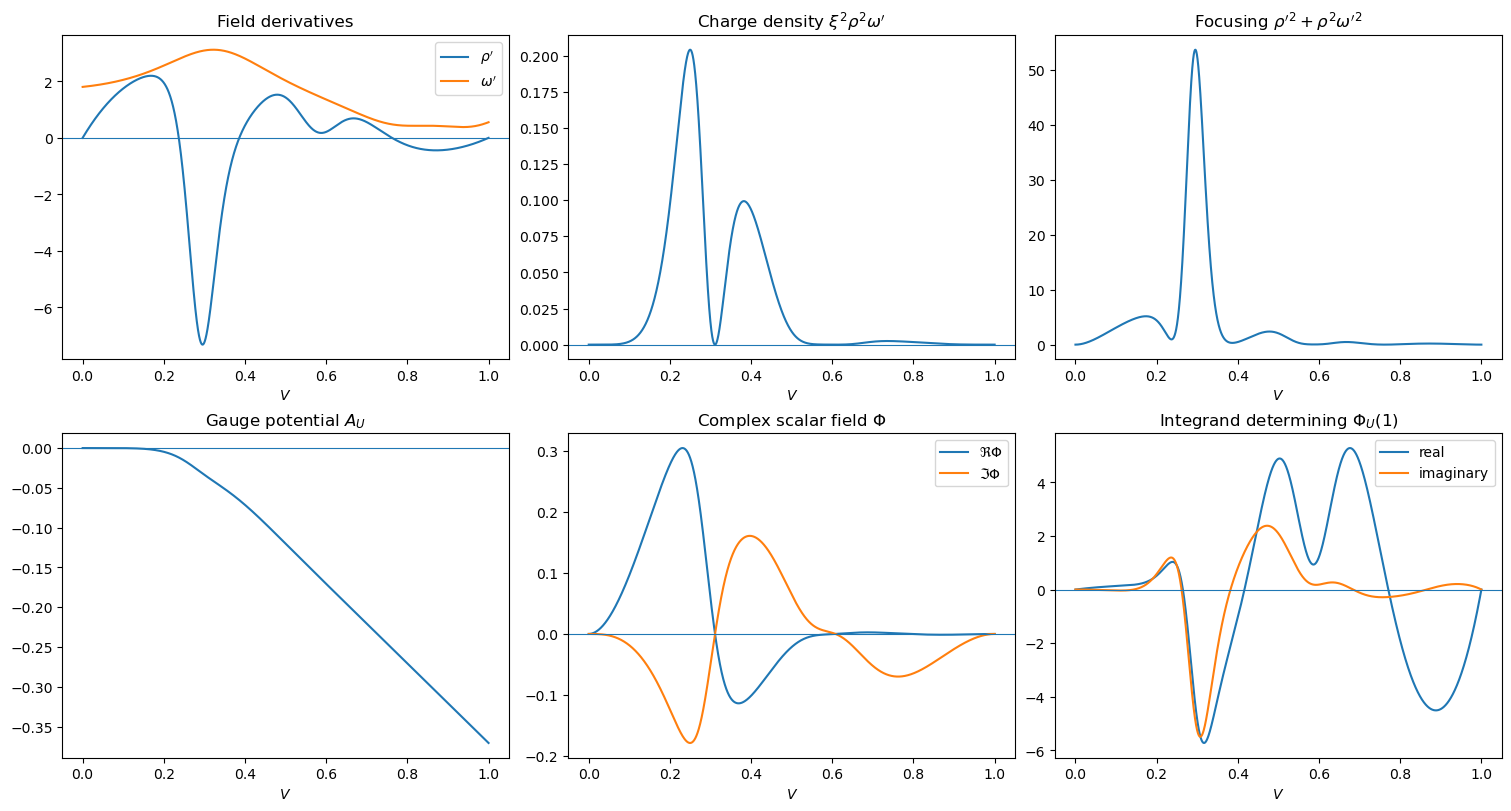

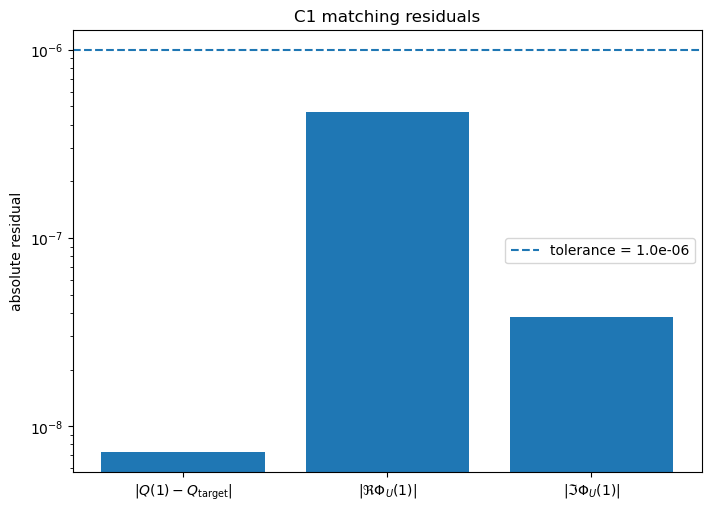

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'C1 matching residuals'}, ylabel='absolute residual'>)

In [157]:
validator.print_C1_validation(validation)

validator.plot_C1_profiles(validation)
validator.plot_C1_diagnostics(validation)
validator.plot_C1_residuals(validation)

In [158]:
fm.save_C1_seed(
    f"seeds/C1_seed_{eM_trial}_p4.npz",
    theta_amp=best_theta_1,
    theta_phase=best_theta_2,
    eM=eM_trial,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    k=1,
    loss=result["best_loss"],
    diagnostics=validation["diagnostics"],)

Saved seed to seeds/C1_seed_35_p4.npz
